In [1]:
import pandas as pd
import numpy as np

In [ ]:
import kagglehub

# Dataset seleccionado: " Car Price Prediction and Vehicle Specifications "
path = kagglehub.dataset_download("ihasan88/car-price-prediction-and-vehicle-specifications")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\BUNJP\.cache\kagglehub\datasets\ihasan88\car-price-prediction-and-vehicle-specifications\versions\1


In [3]:
from pathlib import Path
ruta_csv = next(Path(path).rglob("*.csv"))
df = pd.read_csv(ruta_csv)

EDA
1. Conocer la estructura.
2. Evaluar la calidad de los datos.
3. Analizar variables numéricas y visualizarlas.
4. Analizar variables categóricas y visualizarlas.
5. Detectar e interpretar valores atípicos.
6. Examinar y visualizar relaciones entre variables.

### 1. Conocer la estructura.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   object 
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   object 
 5   Transmission  2000 non-null   object 
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), object(3)
memory usage: 172.0+ KB


In [5]:
df.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [6]:
df.nunique()

Car_ID          2000
Brand              6
Model_Year        19
Engine_Size       41
Fuel_Type          4
Transmission       2
Mileage         1989
Doors              3
Owner_Count        4
Horsepower       329
Price           1998
dtype: int64

### 2. Evaluar la calidad de los datos.

In [7]:
df.isna().sum()  #coincide con Non-Null Count = 0          

Car_ID          0
Brand           0
Model_Year      0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Horsepower      0
Price           0
dtype: int64

In [8]:
df.duplicated().sum()  # Sin duplicados

0

### 3. Analizar variables numéricas y visualizarlas.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Car_ID,2000.0,1000.500000,577.494589,1.00,500.75,1000.50,1500.2500,2000.0
Model_Year,2000.0,2013.963000,5.508248,2005.00,2009.00,2014.00,2019.0000,2023.0
Engine_Size,2000.0,2.967550,1.146926,1.00,2.00,2.90,4.0000,5.0
Mileage,2000.0,100736.956500,56002.915221,5036.00,52365.50,100590.50,148024.5000,199904.0
Doors,2000.0,2.988000,0.818041,2.00,2.00,3.00,4.0000,4.0
Owner_Count,2000.0,2.532500,1.125423,1.00,2.00,3.00,4.0000,4.0
Horsepower,2000.0,235.709500,95.598110,70.00,154.00,236.00,319.0000,399.0
Price,2000.0,46169.507675,9211.685713,18911.55,39764.00,46112.35,52471.3875,72267.8


In [10]:
df.median(numeric_only=True)

Car_ID           1000.50
Model_Year       2014.00
Engine_Size         2.90
Mileage        100590.50
Doors               3.00
Owner_Count         3.00
Horsepower        236.00
Price           46112.35
dtype: float64

In [11]:
# asimetría
df.skew(numeric_only=True)  # Cerca de 0: distribución aproximadamente simétrica.
                            # Valor positivo: cola hacia la derecha.
                            # Valor negativo: cola hacia la izquierda.
                            # Cuanto mayor sea el valor absoluto, mayor es la asimetría.

Car_ID         0.000000
Model_Year     0.019087
Engine_Size    0.034906
Mileage        0.032852
Doors          0.022101
Owner_Count   -0.027288
Horsepower    -0.035397
Price          0.018929
dtype: float64

In [12]:
# curtosis
df.kurt(numeric_only=True)   # Cercana a 0: similar a una distribución normal.
                             # Positiva: más concentrada y con colas más pesadas.
                             # Negativa: más aplanada y con colas más ligeras.

Car_ID        -1.200000
Model_Year    -1.234793
Engine_Size   -1.195073
Mileage       -1.179348
Doors         -1.505346
Owner_Count   -1.376828
Horsepower    -1.191979
Price         -0.332365
dtype: float64

In [13]:
# Elijo solo las columnas numéricas
df.select_dtypes(include=np.number).head()

,Car_ID,Model_Year,Engine_Size,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,2023,1.2,180635,4,3,82,34309.25
1,2,2018,3.2,35628,2,4,259,55153.60
2,3,2008,2.2,74672,3,2,333,41894.40
3,4,2017,2.2,51246,4,4,381,54046.70
4,5,2012,2.4,147233,3,4,290,38010.35


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

columnas = df.select_dtypes(include=np.number).columns

for columna in columnas:
    fig, ax = plt.subplots(1, 2, figsize=(6, 2))

    ax[0].hist(df[columna], bins=30, edgecolor='black')   #df[columna].dropna() si tuviera na
    ax[0].set_title(columna)
    ax[0].tick_params(axis='x', rotation=45)

    ax[1].boxplot(df[columna], vert=False)
    ax[1].set_title('Boxplot')

    plt.tight_layout()
    plt.show()

<Figure size 600x200 with 2 Axes>

<Figure size 600x200 with 2 Axes>

<Figure size 600x200 with 2 Axes>

<Figure size 600x200 with 2 Axes>

<Figure size 600x200 with 2 Axes>

<Figure size 600x200 with 2 Axes>

<Figure size 600x200 with 2 Axes>

<Figure size 600x200 with 2 Axes>

### 4. Analizar variables categóricas y visualizarlas.

Brand
Toyota     352
Hyundai    337
Tesla      330
Honda      329
Ford       326
BMW        326
Name: count, dtype: int64


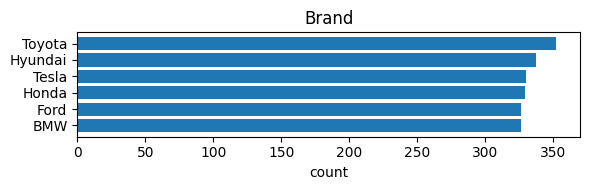

Fuel_Type
Diesel      537
Petrol      511
Electric    484
Hybrid      468
Name: count, dtype: int64


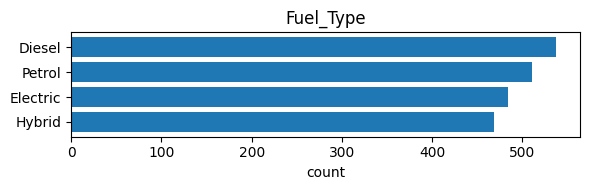

Transmission
Automatic    1018
Manual        982
Name: count, dtype: int64


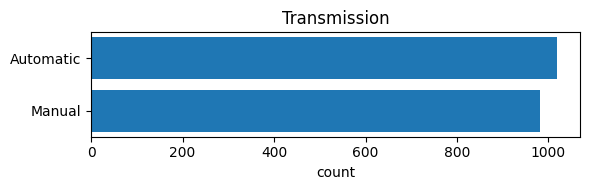

In [15]:
categoricas = df.select_dtypes(include=['object','category']).columns

for columna in categoricas:
    print(df[columna].value_counts(dropna=False))
    #print((df[columna].value_counts(normalize=True)*100).round(2), '\n')  #porcentajes

    vc = df[columna].value_counts()
    plt.figure(figsize=(6, 2) )  #figsize=(6, max(2, 0.35*len(vc))))
    plt.barh(vc.index.astype(str), vc.values)
    plt.gca().invert_yaxis()
    plt.title(columna)
    plt.xlabel('count')
    plt.tight_layout()
    plt.show()

### 5. Detectar e interpretar valores atípicos.

In [16]:
for col in df.select_dtypes(include='number'):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[ (df[col] < limite_inferior) | (df[col] > limite_superior) ]

    print(col, len(outliers))

Car_ID 0
Model_Year 0
Engine_Size 0
Mileage 0
Doors 0
Owner_Count 0
Horsepower 0
Price 2


### 6. Examinar y visualizar relaciones entre variables.

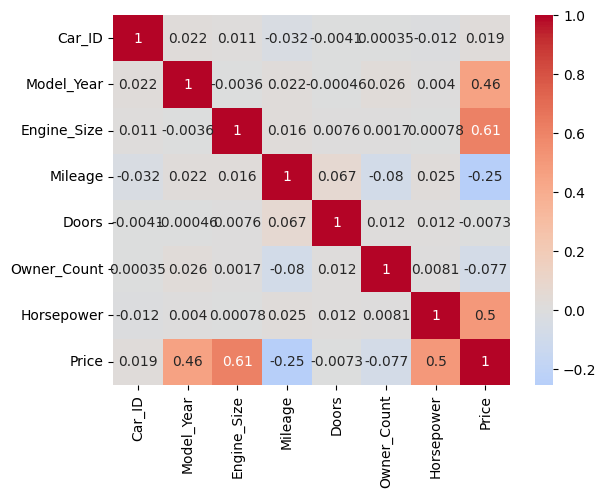

In [17]:
correlacion = df.corr(numeric_only=True, method='spearman')

sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0)
plt.show()

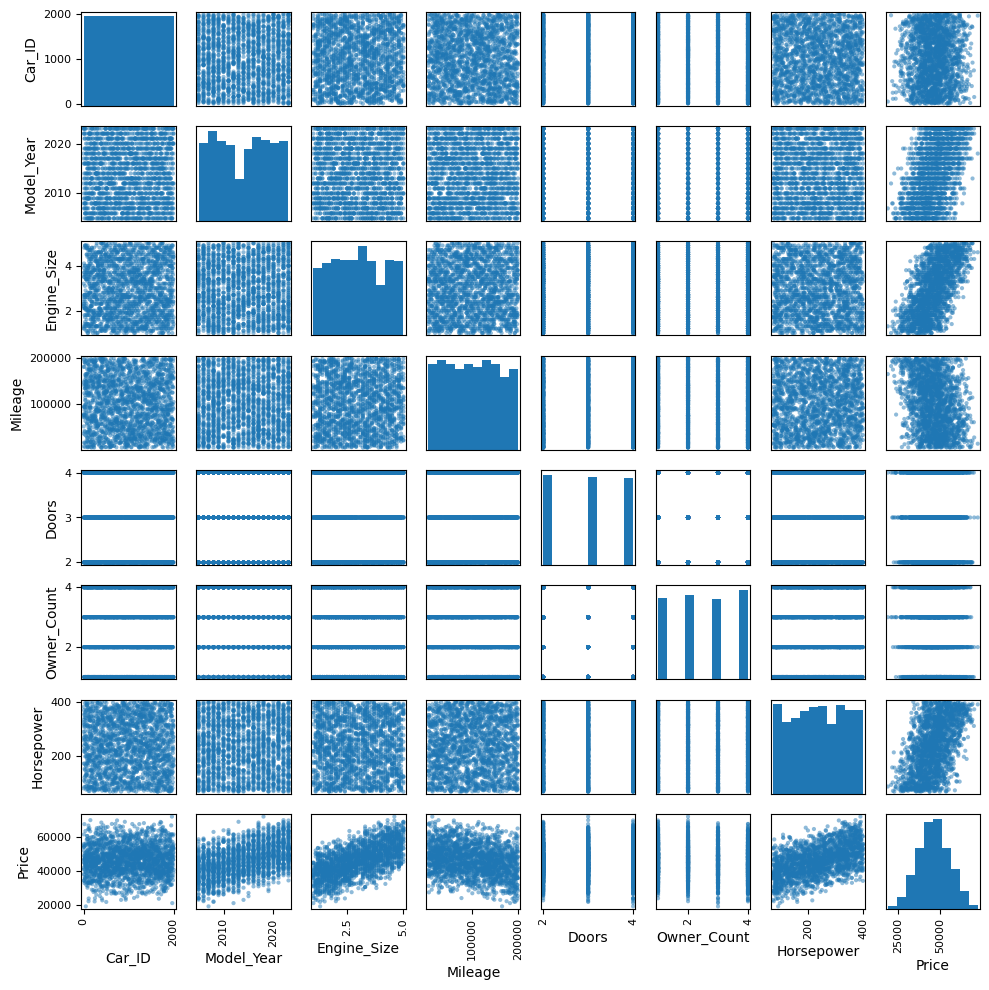

In [18]:
# Relación entre las variables numéricas:

from pandas.plotting import scatter_matrix

columnas_numericas = df.select_dtypes(include='number').columns

scatter_matrix( df[columnas_numericas], figsize=(10, 10), diagonal='hist',  alpha=0.5)

plt.tight_layout()
plt.show()

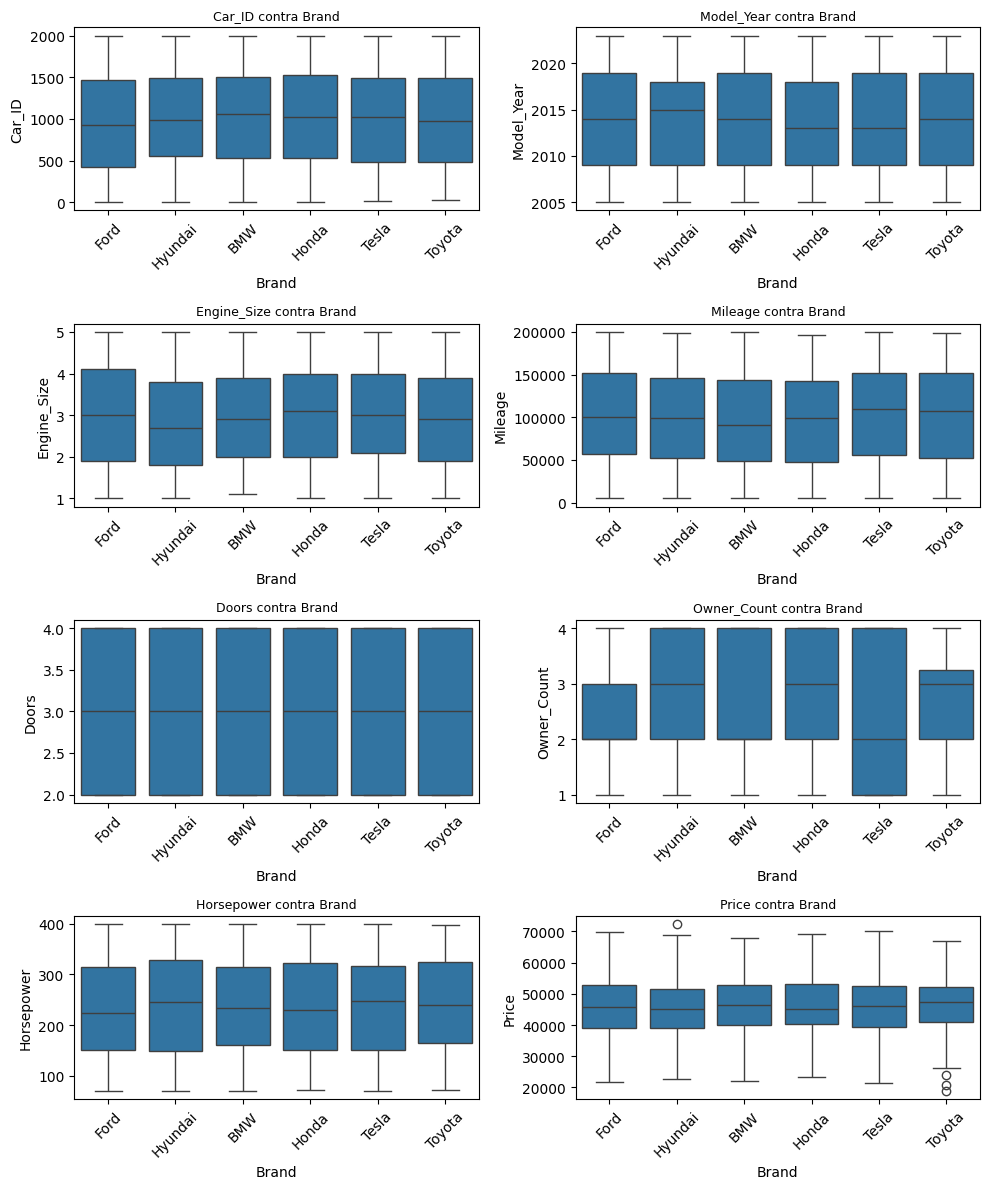

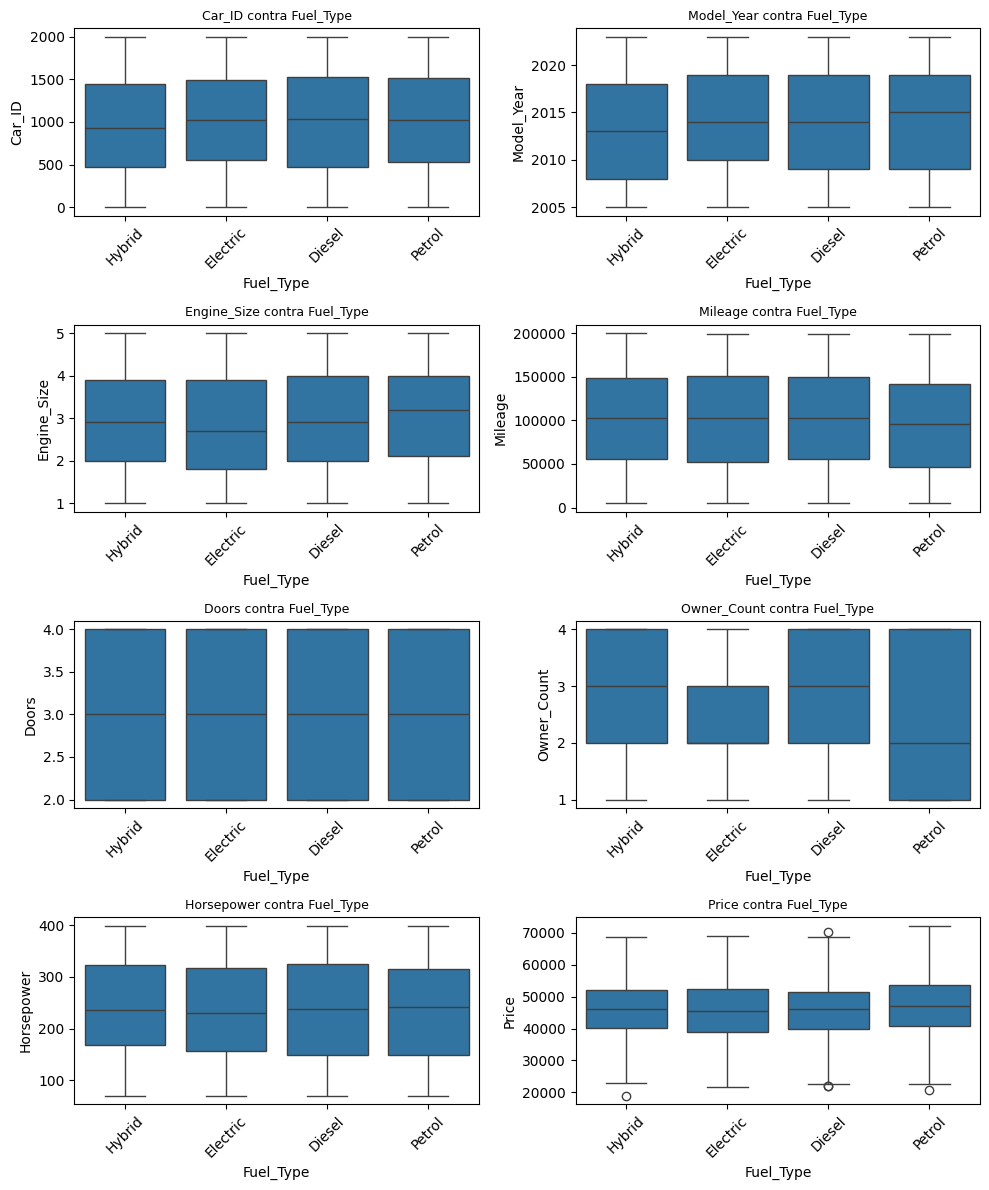

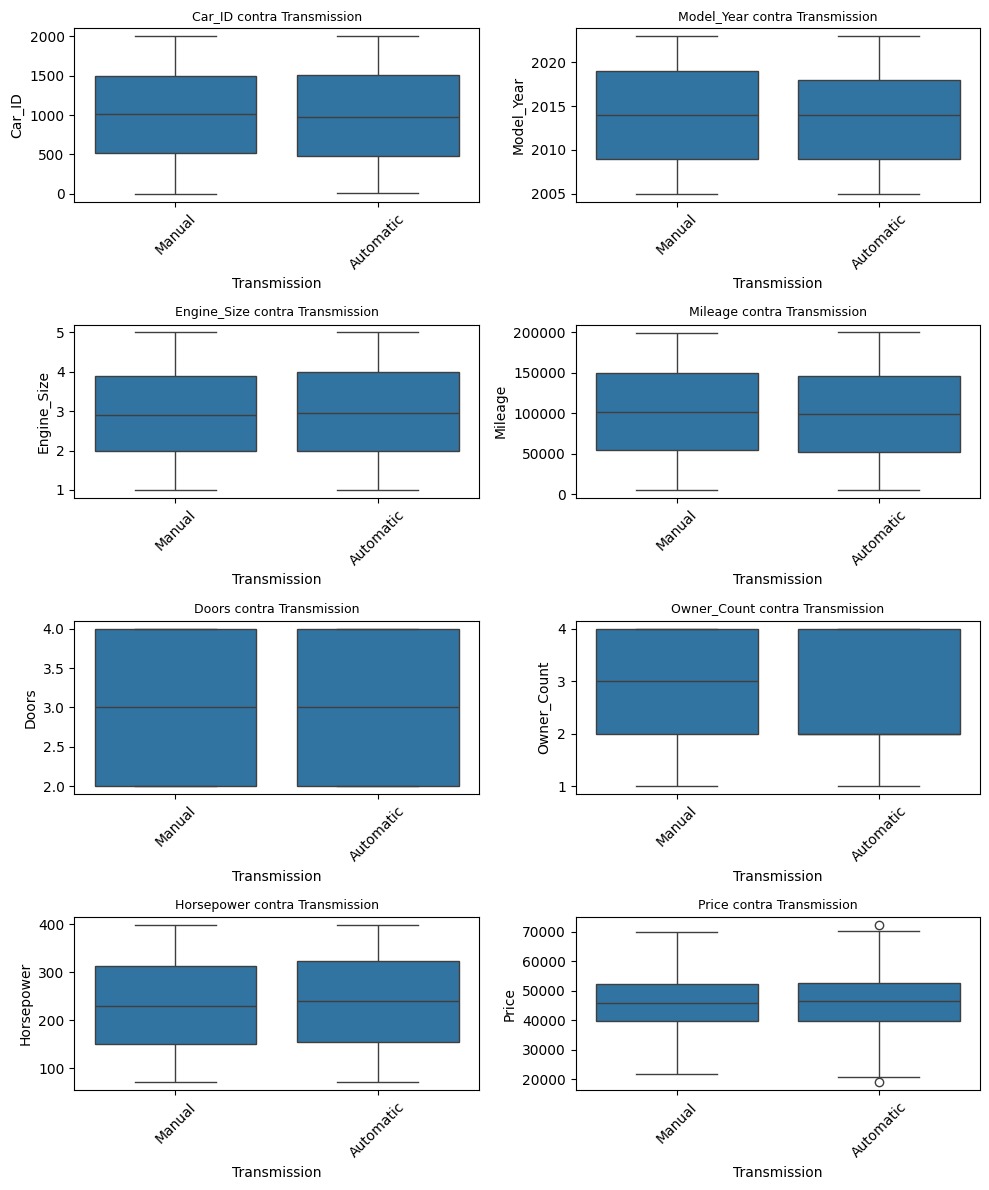

In [21]:
import math

columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns
columnas_numericas = df.select_dtypes(include='number').columns

for categoria in columnas_categoricas:
    n = len(columnas_numericas)
    filas = math.ceil(n / 2)
    fig, axes = plt.subplots(filas, 2, figsize=(10, 3*filas))
    axes = axes.ravel()

    for ax, numerica in zip(axes, columnas_numericas):
        sns.boxplot(data=df, x=categoria, y=numerica, ax=ax)
        ax.set_title(f'{numerica} contra {categoria}', fontsize=9)
        ax.tick_params(axis='x', rotation=45)

    for ax in axes[n:]:          # apaga los ejes sobrantes
        ax.axis('off')

    plt.tight_layout()
    plt.show()

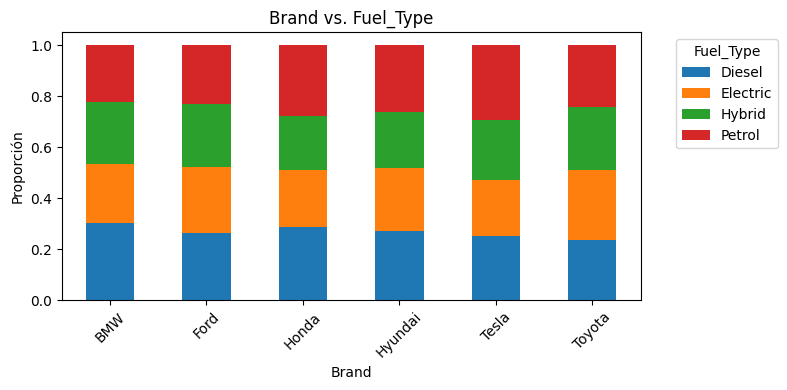

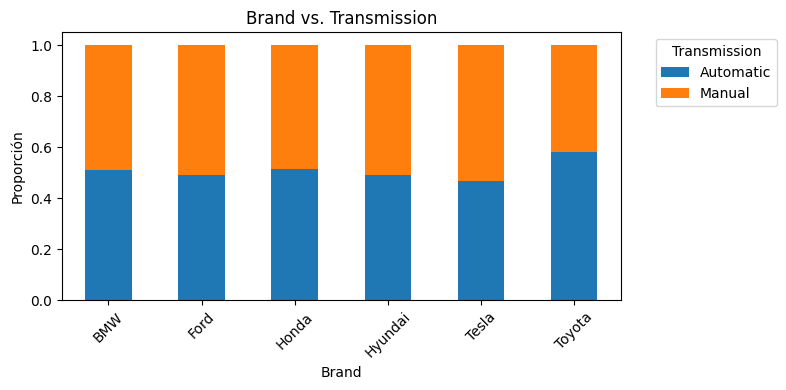

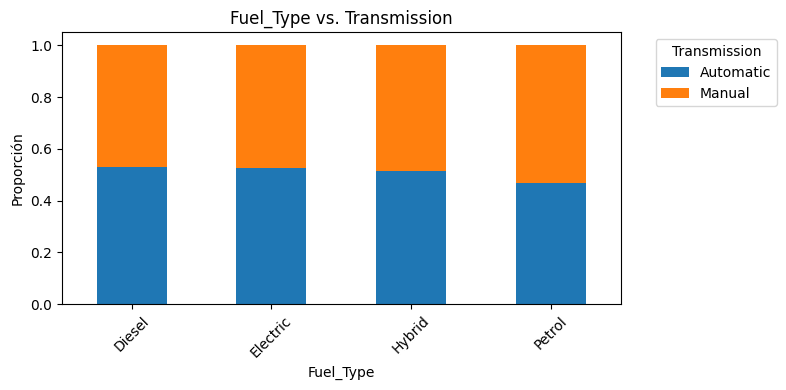

In [20]:
# Categóricas vs categóricas

from itertools import combinations

categoricas = df.select_dtypes(include=['object', 'category', 'bool']).columns

for cat1, cat2 in combinations(categoricas, 2):
    tabla = pd.crosstab( df[cat1], df[cat2], normalize='index'    )

    tabla.plot(kind='bar', stacked=True, figsize=(8, 4)    )

    plt.title(f'{cat1} vs. {cat2}')
    plt.xlabel(cat1)
    plt.ylabel('Proporción')
    plt.xticks(rotation=45)
    plt.legend(title=cat2, bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()